# Learning an Interpretable Traffic Signal Control Policy  
## Simplified DQN and DRHQ-Style Reproduction

**Course:** Deep Reinforcement Learning  
**Assignment:** Research Paper Analysis and Presentation  
**Group:** 100  

**Paper:**  
James Ault, Josiah P. Hanna, and Guni Sharon.  
*Learning an Interpretable Traffic Signal Control Policy.*  
AAMAS 2020.

---

## Group Members

| Contributor | BITS ID |
|---|---:|
| Guduru Sai Deepthi | 2025ag05517 |
| Souhardya Sengupta | 2025ag05033 |
| Sourav Bhattacharya | 2025ag05188 |
| S. Ameer Deen | 2025ag05037 |

---

## Purpose of This Notebook

This notebook provides reproducible evidence for our presentation. It performs the following tasks:

1. Summarizes the paper's objective, methods, findings, limitations, and references.
2. Implements a simplified four-way traffic-intersection environment.
3. Implements an actuated baseline controller.
4. Trains a Deep Q-Network, referred to as the **DQN teacher**.
5. Trains an interpretable precedence function using a **DRHQ-style hardmax imitation objective**.
6. Evaluates all controllers on identical traffic-demand scenarios.
7. Produces tables, figures, CSV files, and PNG files for screenshots and PPT evidence.

> **Academic honesty note:** This is a compact educational implementation inspired by the paper. It does **not** reproduce the paper's exact SUMO map, Utah detector data, 10 phases, 11 non-conflicting phase pairs, 352 parameters, or the paper's reported 19.4 percent delay reduction. Our printed results are results from this simplified experiment only.

# 1. Paper Motivation and Objective

## Direct Links

- **Research paper:** https://arxiv.org/pdf/1912.11023  
- **Authors' experiment repository:** https://github.com/jault/StateStreetSumo  
- **Utah traffic-data portal used by the authors:** https://udottraffic.utah.gov/ATSPM  
- **SUMO traffic simulator:** https://sumo.dlr.de/docs/index.html  

## Motivation

Signalized intersections cause a substantial share of urban travel delay. Deep Reinforcement Learning can optimize traffic signals, but Deep Neural Networks are difficult for traffic engineers, auditors, and public agencies to interpret.

This creates a deployment problem:

- A neural-network controller may produce good delay reduction.
- However, it is difficult to explain why a particular green signal was selected.
- Safety-critical public infrastructure requires accountability, auditing, and human control.
- Engineers should be able to adjust policy behavior without retraining an opaque neural network.

## Main Objective of the Paper

The paper proposes a traffic-signal policy that is both:

1. **Interpretable**: a human can understand the variables and parameters that influence a decision.
2. **Regulatable**: the policy has predictable monotonic behavior and can be manually tuned.

The authors investigate whether an interpretable mathematical control function can learn to behave competitively with a Deep Q-Network while remaining understandable and adjustable.

# 2. MDP Formulation and Regulatable Precedence Function

## Traffic Signal Control as a Markov Decision Process

| MDP Component | Meaning in This Paper |
|---|---|
| State | Current signal configuration and traffic measurements from each lane |
| Action | Select the next non-conflicting green-signal phase combination |
| Transition | Traffic arrivals, vehicle movement, yellow/red clearance intervals, and queue evolution |
| Reward | Reduction in accumulated vehicle delay |
| Discount factor | Determines how much future traffic delay influences current decisions |

The agent selects an action that maximizes expected discounted reward:

$$
J^{\pi} = \sum_{t=0}^{T} \gamma^t r_t
$$

where:

- $\pi$ is the policy;
- $r_t$ is the reward at time step $t$;
- $\gamma$ is the discount factor.

---

## Six Measurable Traffic Variables Used by the Paper

For each traffic phase, the paper uses these non-negative variables:

1. Number of stopped vehicles  
2. Number of approaching vehicles  
3. Cumulative stopped time  
4. Average stopped time  
5. Average queue length  
6. Average speed of approaching vehicles  

The paper also uses four clearance indicators:

- Full clearance
- Partial clearance
- Permissive clearance
- No clearance

---

## Original Regulatable Precedence Function

The paper assigns a precedence score to every candidate non-conflicting phase set $\Phi$:

$$
G(s,\Phi;\theta') =
\sum_{\phi \in \Phi}
\sum_{i=1}^{6}
\left(w_i^{\Phi\phi}s[i]\right)^{p_i^{\Phi\phi}}
\cdot
\sum_{j=1}^{4}
\left(w_j^{\prime\Phi}f_j\right)^{p_j^{\prime\Phi}}
$$

The controller selects the phase combination with the highest score:

$$
\pi(s) = \arg\max_{\Phi} G(s,\Phi;\theta')
$$

---

## Why the Policy Is Regulatable

A precedence function is regulatable when its derivative with respect to each state variable is always non-negative or always non-positive:

$$
\frac{\partial G}{\partial s[i]} \geq 0
\quad \text{or} \quad
\frac{\partial G}{\partial s[i]} \leq 0
$$

This gives predictable behavior. For example, if the number of stopped vehicles on a movement increases, the urgency of serving that movement should not unexpectedly decrease.

### Install/Import Libraries and Create Output Folder

In [ ]:
# This cell is executable in Google Colab.

import os
import random
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from IPython.display import display, Markdown

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Folder containing all proof-of-work artifacts
OUTPUT_DIR = Path("traffic_signal_proof_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup completed successfully.")
print("PyTorch device:", DEVICE)
print("Output folder:", OUTPUT_DIR.resolve())

Setup completed successfully.
PyTorch device: cuda
Output folder: /content/traffic_signal_proof_outputs


# 3. Experimental Scope

## What the Original Paper Did

The original paper used:

- SUMO, a detailed traffic simulator;
- a real intersection at State Street and East 4500 South, Murray, Utah;
- Utah Department of Transportation traffic-demand observations;
- 10 traffic phases;
- 11 non-conflicting phase combinations;
- 352 tunable parameters in the designed precedence policy;
- three 14-hour traffic scenarios from 2019;
- DQN, CMA-ES, PPO, DRQ, DRSQ, and DRHQ comparisons.

## What This Notebook Does

This notebook is a compact proof-of-work implementation.

| Component | Original Paper | This Notebook |
|---|---|---|
| Intersection | Real Utah intersection in SUMO | Simplified four-way intersection |
| Traffic phases | 10 phases | Two phase groups: NS and EW |
| State variables | Six per phase plus clearance flags | Six simplified measurable features plus switching flag |
| Teacher | DQN trained in SUMO | Small DQN trained in simplified simulator |
| Student | Full regulatable polynomial function | Monotonic precedence-score student |
| Student objective | DRQ, DRSQ, DRHQ variants | DRHQ-style hardmax imitation |
| Result | Up to 19.4% delay reduction | Results printed after executing this notebook |

> We implemented a simplified DQN-to-regulatable-policy experiment to demonstrate the mechanism of DRHQ-style policy imitation. Our values are not claimed as an exact reproduction of the paper’s SUMO results.

### Display Paper Facts and Paper Demand Table

In [ ]:
# Paper facts and reported traffic-demand profiles.
# This table is based on the paper's Table 1.

paper_demand_table = pd.DataFrame({
    "Demand Level": ["Low", "Medium", "High"],
    "Representative Date": [
        "Monday, May 6, 2019",
        "Wednesday, May 1, 2019",
        "Friday, June 21, 2019"
    ],
    "Total Vehicles": [45112, 51298, 61261],
    "Average Rate (vehicles/sec)": [1.04, 1.19, 1.42],
    "Off-Peak Rate (vehicles/sec)": [0.59, 0.76, 0.98],
    "Peak-Hour Rate (vehicles/sec)": [1.29, 1.42, 1.59]
})

print("TABLE A: Traffic demand profiles reported in the research paper")
display(paper_demand_table)

paper_summary = pd.DataFrame({
    "Paper Finding": [
        "DRHQ result",
        "DQN result",
        "PPO result",
        "CMA-ES result"
    ],
    "Interpretation": [
        "DRHQ achieved up to 19.4% reduced delay relative to the actuated baseline.",
        "DQN achieved the strongest delay performance but remained uninterpretable.",
        "PPO had smoother learning but slower and weaker convergence, especially at high demand.",
        "CMA-ES could tune the function but required inefficient and potentially unsafe exploration."
    ]
})

print("\nTABLE B: Main findings reported by the paper")
display(paper_summary)

paper_demand_table.to_csv(OUTPUT_DIR / "paper_traffic_demand_table.csv", index=False)
paper_summary.to_csv(OUTPUT_DIR / "paper_findings_summary.csv", index=False)

print("\nSaved paper tables as CSV files.")

TABLE A: Traffic demand profiles reported in the research paper


,Demand Level,Representative Date,Total Vehicles,Average Rate (vehicles/sec),Off-Peak Rate (vehicles/sec),Peak-Hour Rate (vehicles/sec)
0,Low,"Monday, May 6, 2019",45112,1.04,0.59,1.29
1,Medium,"Wednesday, May 1, 2019",51298,1.19,0.76,1.42
2,High,"Friday, June 21, 2019",61261,1.42,0.98,1.59



TABLE B: Main findings reported by the paper


,Paper Finding,Interpretation
0,DRHQ result,DRHQ achieved up to 19.4% reduced delay relati...
1,DQN result,DQN achieved the strongest delay performance b...
2,PPO result,PPO had smoother learning but slower and weake...
3,CMA-ES result,CMA-ES could tune the function but required in...



Saved paper tables as CSV files.


# 4. Simplified Traffic Environment

We model one four-way intersection with four incoming approaches:

- North
- East
- South
- West

The controller can select one of two non-conflicting signal groups:

| Action | Green Movements |
|---|---|
| **NS** | North and South |
| **EW** | East and West |

## Simplified State Features

For each candidate signal group, the environment computes six non-negative features:

1. Stopped vehicles  
2. Approaching vehicles  
3. Cumulative waiting time  
4. Average waiting time  
5. Average queue length  
6. Approximate average approaching speed  

A phase-switch flag is also added. Switching from NS to EW, or from EW to NS, has a one-step clearance cost in this simplified model.

## Reward

The DQN teacher receives a negative reward when queues and delays increase:

$$
r_t = - \left(\text{number of waiting vehicles} + 0.05 \times \text{total waiting time}\right)
$$

Therefore, maximizing cumulative reward encourages lower queues and lower delay.

### Simplified Four-Way Traffic Environment

In [ ]:
APPROACHES = ["North", "East", "South", "West"]

# Action 0 means North-South is green.
# Action 1 means East-West is green.
ACTION_NAMES = {
    0: "NS",
    1: "EW"
}

ACTION_LANES = {
    0: [0, 2],  # North and South
    1: [1, 3]   # East and West
}


class SimplifiedTrafficEnv:
    """
    Simplified four-way traffic intersection.

    This is an educational environment designed to demonstrate:
    - an actuated baseline;
    - a DQN teacher;
    - a DRHQ-style interpretable student.

    It is not a SUMO reproduction.
    """

    def __init__(self, horizon=160, demand_level="medium", seed=42):
        self.horizon = horizon
        self.demand_level = demand_level
        self.base_seed = seed
        self.service_rate = 2
        self.reset(seed)

    def _create_demand_profile(self):
        if self.demand_level == "low":
            base_rates = np.array([0.45, 0.30, 0.42, 0.28])

        elif self.demand_level == "medium":
            base_rates = np.array([0.72, 0.48, 0.68, 0.45])

        elif self.demand_level == "high":
            base_rates = np.array([0.95, 0.70, 0.92, 0.66])

        else:
            raise ValueError("demand_level must be low, medium, or high")

        time_effect = 1.0 + 0.30 * np.sin(
            np.linspace(0, 3 * np.pi, self.horizon)
        ) ** 2

        return np.outer(time_effect, base_rates)

    def reset(self, seed=None):
        if seed is None:
            seed = self.base_seed

        self.rng = np.random.default_rng(seed)
        self.demand_profile = self._create_demand_profile()

        # Every queue stores one waiting-time value for each vehicle.
        self.queues = [[] for _ in range(4)]

        self.time_step = 0
        self.last_action = 0

        self.total_departed = 0
        self.total_departed_delay = 0

        self.queue_history = []
        self.delay_history = []
        self.action_history = []

        return self.get_state()

    def _phase_features(self, action):
        lane_indices = ACTION_LANES[action]

        stopped = sum(len(self.queues[lane]) for lane in lane_indices)

        approaching = self.demand_profile[
            min(self.time_step, self.horizon - 1),
            lane_indices
        ].sum()

        cumulative_wait = sum(
            sum(self.queues[lane])
            for lane in lane_indices
        )

        average_wait = cumulative_wait / stopped if stopped > 0 else 0.0

        average_queue_length = stopped / len(lane_indices)

        # A simple proxy: more queueing means lower approaching speed.
        average_speed = approaching / (1.0 + stopped)

        # Feature scaling improves neural-network stability.
        return np.array([
            stopped / 20.0,
            approaching / 4.0,
            cumulative_wait / 100.0,
            average_wait / 10.0,
            average_queue_length / 10.0,
            average_speed
        ], dtype=np.float32)

    def get_state(self):
        ns_features = self._phase_features(0)
        ew_features = self._phase_features(1)

        # Switching action implies a clearance delay.
        ns_switch_flag = float(self.last_action != 0)
        ew_switch_flag = float(self.last_action != 1)

        last_action_one_hot = np.array([
            float(self.last_action == 0),
            float(self.last_action == 1)
        ], dtype=np.float32)

        state = np.concatenate([
            ns_features,
            ew_features,
            np.array([ns_switch_flag, ew_switch_flag], dtype=np.float32),
            last_action_one_hot
        ])

        return state.astype(np.float32)

    def step(self, action):
        # 1. New vehicles arrive.
        arrivals = self.rng.poisson(
            self.demand_profile[self.time_step]
        )

        for lane_index, number_of_arrivals in enumerate(arrivals):
            self.queues[lane_index].extend([0] * int(number_of_arrivals))

        # 2. A phase change produces a one-step simplified clearance period.
        phase_changed = action != self.last_action

        if not phase_changed:
            for lane_index in ACTION_LANES[action]:
                number_served = min(
                    self.service_rate,
                    len(self.queues[lane_index])
                )

                departed_waits = self.queues[lane_index][:number_served]
                self.queues[lane_index] = self.queues[lane_index][number_served:]

                self.total_departed += number_served
                self.total_departed_delay += sum(departed_waits)

        # 3. All remaining vehicles wait for one step.
        for lane_index in range(4):
            self.queues[lane_index] = [
                waiting_time + 1
                for waiting_time in self.queues[lane_index]
            ]

        self.last_action = action
        self.time_step += 1

        total_queue = sum(len(queue) for queue in self.queues)
        total_wait = sum(sum(queue) for queue in self.queues)

        reward = -(total_queue + 0.05 * total_wait)

        self.queue_history.append(total_queue)
        self.delay_history.append(total_wait)
        self.action_history.append(action)

        done = self.time_step >= self.horizon

        info = {
            "total_queue": total_queue,
            "total_wait": total_wait,
            "phase_changed": phase_changed
        }

        return self.get_state(), reward, done, info


def calculate_episode_metrics(environment):
    remaining_vehicles = sum(len(queue) for queue in environment.queues)
    remaining_delay = sum(sum(queue) for queue in environment.queues)

    total_vehicles = environment.total_departed + remaining_vehicles
    total_delay = environment.total_departed_delay + remaining_delay

    average_delay = total_delay / total_vehicles if total_vehicles > 0 else 0.0

    return {
        "average_delay": average_delay,
        "cumulative_queue": float(sum(environment.queue_history)),
        "vehicles_departed": environment.total_departed,
        "remaining_vehicles": remaining_vehicles,
        "total_vehicles": total_vehicles
    }


print("Simplified traffic environment created successfully.")
print("State vector size:", len(SimplifiedTrafficEnv().reset()))

Simplified traffic environment created successfully.
State vector size: 16


### Create an Intersection Figure

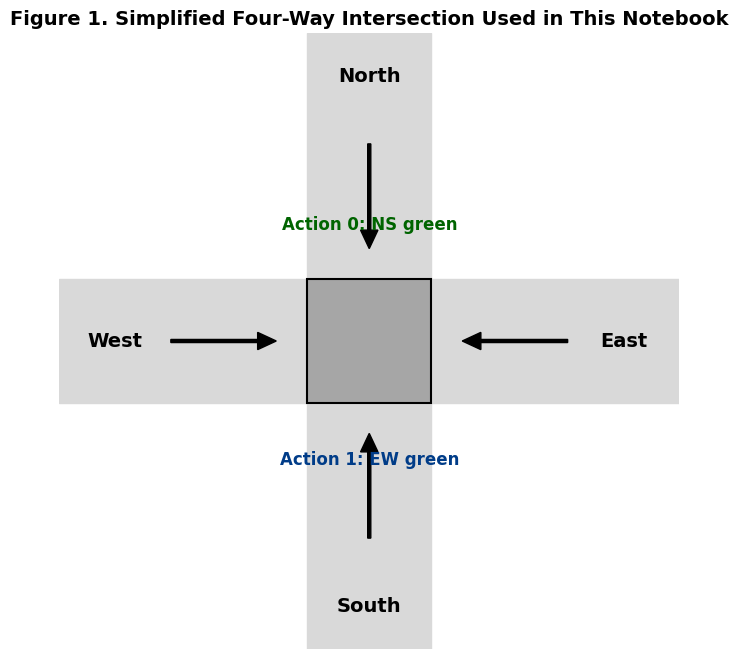

Saved figure: traffic_signal_proof_outputs/simplified_intersection_diagram.png


In [ ]:
# This code creates a clean figure showing the simplified intersection.

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Roads
ax.add_patch(plt.Rectangle((4, 0), 2, 10, color="#D9D9D9"))
ax.add_patch(plt.Rectangle((0, 4), 10, 2, color="#D9D9D9"))

# Intersection box
ax.add_patch(
    plt.Rectangle(
        (4, 4), 2, 2,
        facecolor="#A6A6A6",
        edgecolor="black",
        linewidth=1.5
    )
)

# Direction labels
ax.text(5, 9.3, "North", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(5, 0.7, "South", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(0.9, 5, "West", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(9.1, 5, "East", ha="center", va="center", fontsize=14, fontweight="bold")

# Signal phase labels
ax.text(
    5, 6.8,
    "Action 0: NS green",
    ha="center",
    fontsize=12,
    color="#006400",
    fontweight="bold"
)

ax.text(
    5, 3.0,
    "Action 1: EW green",
    ha="center",
    fontsize=12,
    color="#003C88",
    fontweight="bold"
)

# Arrows
arrow_style = dict(width=0.05, head_width=0.28, head_length=0.30, color="black")

ax.arrow(5, 8.2, 0, -1.4, **arrow_style)
ax.arrow(5, 1.8, 0, 1.4, **arrow_style)
ax.arrow(1.8, 5, 1.4, 0, **arrow_style)
ax.arrow(8.2, 5, -1.4, 0, **arrow_style)

plt.title(
    "Figure 1. Simplified Four-Way Intersection Used in This Notebook",
    fontsize=14,
    fontweight="bold"
)

figure_path = OUTPUT_DIR / "simplified_intersection_diagram.png"
plt.savefig(figure_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

# 5. Algorithms Implemented

## A. Actuated Baseline

The actuated baseline selects the phase with the largest current stopped-vehicle queue.

This is a simplified version of a practical queue-responsive controller.

## B. DQN Teacher

The DQN teacher is a neural network that estimates an action value for each possible phase:

$$
Q(s, a; \theta)
$$

The DQN selects:

$$
a_t = \arg\max_a Q(s_t, a; \theta)
$$

The DQN is powerful but not easily interpretable because its decisions are represented through hidden neural-network weights.

## C. DRHQ-Style Interpretable Student

The interpretable student assigns a score to each action using non-negative feature weights and bounded exponents:

$$
G(s, a; \tilde{\theta}) =
\sum_{i=1}^{6}
\left(w_{a,i}x_{a,i}\right)^{p_{a,i}}
-
c_a \times \text{SwitchFlag}(a)
$$

where:

- $x_{a,i}$ is one of the six traffic features for action $a$;
- $w_{a,i} \geq 0$ is a learned interpretable weight;
- $p_{a,i} > 0$ is a learned exponent;
- $c_a \geq 0$ penalizes phase switching;
- the switch flag represents simplified clearance cost.

The DRHQ objective uses the DQN teacher's preferred action as the target:

$$
y =
\begin{cases}
1, & \text{for the DQN teacher's preferred action} \\
0, & \text{otherwise}
\end{cases}
$$

The student is trained using cross-entropy loss between the teacher's hard action label and the softmax of the student's precedence scores.

### Actuated Baseline, DQN Teacher, Replay Buffer, and Training

In [ ]:
STATE_DIM = 16
ACTION_DIM = 2


def actuated_policy(state):
    """
    Select the action with the larger stopped-vehicle feature.
    NS stopped feature is state[0].
    EW stopped feature is state[6].
    """
    north_south_stopped = state[0]
    east_west_stopped = state[6]

    return 0 if north_south_stopped >= east_west_stopped else 1


class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states = np.array([item[0] for item in batch], dtype=np.float32)
        actions = np.array([item[1] for item in batch], dtype=np.int64)
        rewards = np.array([item[2] for item in batch], dtype=np.float32)
        next_states = np.array([item[3] for item in batch], dtype=np.float32)
        dones = np.array([item[4] for item in batch], dtype=np.float32)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, state):
        return self.network(state)


def train_dqn(
    demand_level="medium",
    episodes=120,
    horizon=160,
    gamma=0.95,
    learning_rate=0.001,
    batch_size=64,
    target_update_interval=10
):
    """
    Train a compact DQN teacher in the simplified environment.
    """

    q_network = DQN().to(DEVICE)
    target_network = DQN().to(DEVICE)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
    replay_buffer = ReplayBuffer(capacity=20000)

    episode_rewards = []
    episode_average_delays = []

    for episode in range(episodes):
        environment = SimplifiedTrafficEnv(
            horizon=horizon,
            demand_level=demand_level,
            seed=SEED + episode
        )

        state = environment.reset(seed=SEED + episode)

        epsilon = max(0.02, 0.30 * (1 - episode / episodes))
        cumulative_reward = 0.0
        done = False

        while not done:
            if random.random() < epsilon:
                action = random.randint(0, 1)
            else:
                state_tensor = torch.tensor(
                    state,
                    dtype=torch.float32,
                    device=DEVICE
                ).unsqueeze(0)

                with torch.no_grad():
                    action = int(torch.argmax(q_network(state_tensor), dim=1).item())

            next_state, reward, done, _ = environment.step(action)

            replay_buffer.add(
                state,
                action,
                reward,
                next_state,
                float(done)
            )

            state = next_state
            cumulative_reward += reward

            if len(replay_buffer) >= batch_size:
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                states_tensor = torch.tensor(states, dtype=torch.float32, device=DEVICE)
                actions_tensor = torch.tensor(actions, dtype=torch.int64, device=DEVICE)
                rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
                next_states_tensor = torch.tensor(next_states, dtype=torch.float32, device=DEVICE)
                dones_tensor = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

                current_q_values = q_network(states_tensor).gather(
                    1,
                    actions_tensor.unsqueeze(1)
                ).squeeze(1)

                with torch.no_grad():
                    next_q_values = target_network(next_states_tensor).max(dim=1)[0]
                    target_q_values = rewards_tensor + gamma * (1 - dones_tensor) * next_q_values

                loss = F.smooth_l1_loss(current_q_values, target_q_values)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_network.parameters(), max_norm=5.0)
                optimizer.step()

        if (episode + 1) % target_update_interval == 0:
            target_network.load_state_dict(q_network.state_dict())

        metrics = calculate_episode_metrics(environment)
        episode_rewards.append(cumulative_reward)
        episode_average_delays.append(metrics["average_delay"])

    return q_network, replay_buffer, episode_rewards, episode_average_delays


print("Starting DQN teacher training. This may take approximately 1 to 3 minutes in Colab.")

dqn_teacher, replay_memory, training_rewards, training_delays = train_dqn()

print("DQN teacher training completed.")
print("Replay-memory size:", len(replay_memory))

Starting DQN teacher training. This may take approximately 1 to 3 minutes in Colab.
DQN teacher training completed.
Replay-memory size: 19200


### Plot DQN Training Curves

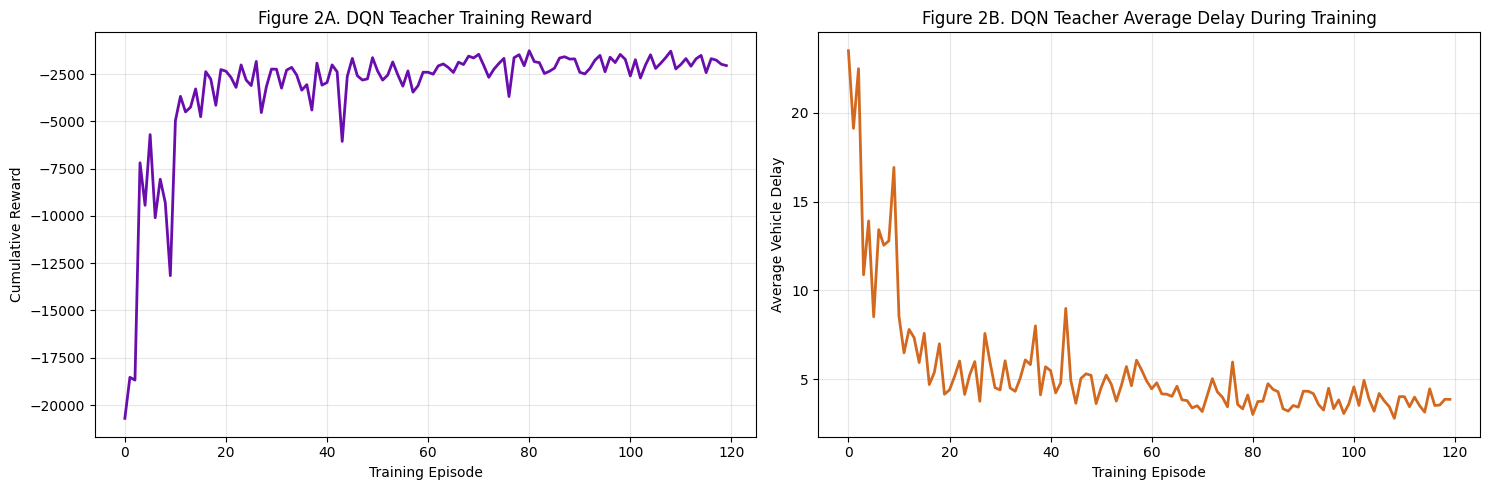

Saved training figure: traffic_signal_proof_outputs/dqn_teacher_training_curves.png


,Episode,Cumulative Reward,Average Delay
110,111,-1992.35,4.014
111,112,-1680.70,3.448
112,113,-2082.80,3.986
113,114,-1694.00,3.508
114,115,-1511.55,3.142
115,116,-2422.50,4.453
116,117,-1685.30,3.517
117,118,-1764.00,3.543
118,119,-1980.05,3.868
119,120,-2051.15,3.864


In [ ]:
# Plot teacher training performance.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(training_rewards, color="#6A0DAD", linewidth=2)
axes[0].set_title("Figure 2A. DQN Teacher Training Reward")
axes[0].set_xlabel("Training Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].grid(alpha=0.3)

axes[1].plot(training_delays, color="#D2691E", linewidth=2)
axes[1].set_title("Figure 2B. DQN Teacher Average Delay During Training")
axes[1].set_xlabel("Training Episode")
axes[1].set_ylabel("Average Vehicle Delay")
axes[1].grid(alpha=0.3)

plt.tight_layout()

training_plot_path = OUTPUT_DIR / "dqn_teacher_training_curves.png"
plt.savefig(training_plot_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved training figure:", training_plot_path)

training_history = pd.DataFrame({
    "Episode": np.arange(1, len(training_rewards) + 1),
    "Cumulative Reward": training_rewards,
    "Average Delay": training_delays
})

training_history.to_csv(
    OUTPUT_DIR / "dqn_teacher_training_history.csv",
    index=False
)

display(training_history.tail(10).round(3))

## DRHQ-Style Imitation Training

# 6. DRHQ-Style Hardmax Imitation

The paper introduces three DQN-assisted methods for training a regulatable policy:

| Method | Main Idea |
|---|---|
| **DRQ** | Make the precedence score match the DQN's numerical Q-value |
| **DRSQ** | Make the softmax action distribution of the precedence model match the DQN |
| **DRHQ** | Make the precedence model select the same highest-value action as the DQN |

## Why DRHQ Is Important

DRHQ does **not** require the interpretable function to reproduce every Q-value exactly.

It only requires policy agreement:

$$
\arg\max_a G(s,a;\tilde{\theta})
=
\arg\max_a Q(s,a;\theta)
$$

This is important because an interpretable formula has far fewer parameters and less representational flexibility than a deep neural network.

In the next cell:

1. States are collected from the DQN teacher's replay memory.
2. The DQN teacher assigns its preferred action to each state.
3. The interpretable student learns to imitate those hard action labels.
4. The student remains transparent because its parameters correspond to visible traffic features.

### Train the Interpretable DRHQ-Style Student

In [ ]:
class RegulatableStudent(nn.Module):
    """
    Simplified interpretable precedence model.

    For each action and feature:
    - weights are constrained to be non-negative;
    - exponents are constrained between 0.5 and 2.0;
    - switching penalties are constrained to be non-negative.

    This preserves monotonicity with respect to positive traffic features.
    """

    def __init__(self):
        super().__init__()

        # One raw weight and exponent per action-feature pair.
        self.raw_weights = nn.Parameter(torch.zeros(2, 6))
        self.raw_exponents = nn.Parameter(torch.zeros(2, 6))

        # One switching penalty for each candidate action.
        self.raw_switch_penalty = nn.Parameter(torch.tensor([0.0, 0.0]))

    def forward(self, states):
        # First 12 state values = 6 features for NS and 6 for EW.
        phase_features = states[:, :12].reshape(-1, 2, 6)

        # Values 12 and 13 = switching flags for NS and EW.
        switch_flags = states[:, 12:14]

        # All feature weights are non-negative.
        weights = F.softplus(self.raw_weights) + 1e-4

        # Exponents stay in the interval [0.5, 2.0].
        exponents = 0.5 + 1.5 * torch.sigmoid(self.raw_exponents)

        # Switching penalties are non-negative.
        switch_penalties = F.softplus(self.raw_switch_penalty)

        weighted_features = torch.clamp(
            phase_features * weights.unsqueeze(0),
            min=1e-6
        )

        feature_scores = torch.pow(
            weighted_features,
            exponents.unsqueeze(0)
        ).sum(dim=2)

        precedence_scores = feature_scores - switch_penalties.unsqueeze(0) * switch_flags

        return precedence_scores

    def readable_parameters(self):
        weights = (F.softplus(self.raw_weights) + 1e-4).detach().cpu().numpy()
        exponents = (
            0.5 + 1.5 * torch.sigmoid(self.raw_exponents)
        ).detach().cpu().numpy()
        penalties = F.softplus(self.raw_switch_penalty).detach().cpu().numpy()

        return weights, exponents, penalties


# Obtain states from replay memory.
replay_states = np.array(
    [transition[0] for transition in replay_memory.buffer],
    dtype=np.float32
)

# Limit training states for fast Colab execution.
maximum_student_samples = min(8000, len(replay_states))
selected_indices = np.random.choice(
    len(replay_states),
    size=maximum_student_samples,
    replace=False
)

student_states = replay_states[selected_indices]

# DQN teacher produces hardmax action labels.
dqn_teacher.eval()

with torch.no_grad():
    teacher_state_tensor = torch.tensor(
        student_states,
        dtype=torch.float32,
        device=DEVICE
    )

    teacher_actions = torch.argmax(
        dqn_teacher(teacher_state_tensor),
        dim=1
    ).cpu().numpy()

# Train/test split for imitation-fidelity reporting.
split_index = int(0.80 * len(student_states))

train_states = student_states[:split_index]
train_labels = teacher_actions[:split_index]

test_states = student_states[split_index:]
test_labels = teacher_actions[split_index:]

student_model = RegulatableStudent().to(DEVICE)
student_optimizer = optim.Adam(student_model.parameters(), lr=0.03)

student_loss_history = []
student_accuracy_history = []

for epoch in range(500):
    permutation = np.random.permutation(len(train_states))

    shuffled_states = train_states[permutation]
    shuffled_labels = train_labels[permutation]

    batch_losses = []
    batch_accuracies = []

    for start_index in range(0, len(shuffled_states), 128):
        end_index = start_index + 128

        state_batch = torch.tensor(
            shuffled_states[start_index:end_index],
            dtype=torch.float32,
            device=DEVICE
        )

        label_batch = torch.tensor(
            shuffled_labels[start_index:end_index],
            dtype=torch.long,
            device=DEVICE
        )

        student_scores = student_model(state_batch)
        loss = F.cross_entropy(student_scores, label_batch)

        student_optimizer.zero_grad()
        loss.backward()
        student_optimizer.step()

        predictions = torch.argmax(student_scores, dim=1)
        accuracy = (predictions == label_batch).float().mean().item()

        batch_losses.append(loss.item())
        batch_accuracies.append(accuracy)

    student_loss_history.append(np.mean(batch_losses))
    student_accuracy_history.append(np.mean(batch_accuracies))

# Test imitation fidelity.
student_model.eval()

with torch.no_grad():
    test_state_tensor = torch.tensor(
        test_states,
        dtype=torch.float32,
        device=DEVICE
    )

    student_test_predictions = torch.argmax(
        student_model(test_state_tensor),
        dim=1
    ).cpu().numpy()

test_imitation_accuracy = np.mean(
    student_test_predictions == test_labels
)

print("DRHQ-style interpretable student training completed.")
print("Student test imitation accuracy:", round(test_imitation_accuracy * 100, 2), "%")

DRHQ-style interpretable student training completed.
Student test imitation accuracy: 95.12 %


### Plot Student Training and Display Interpretable Parameters

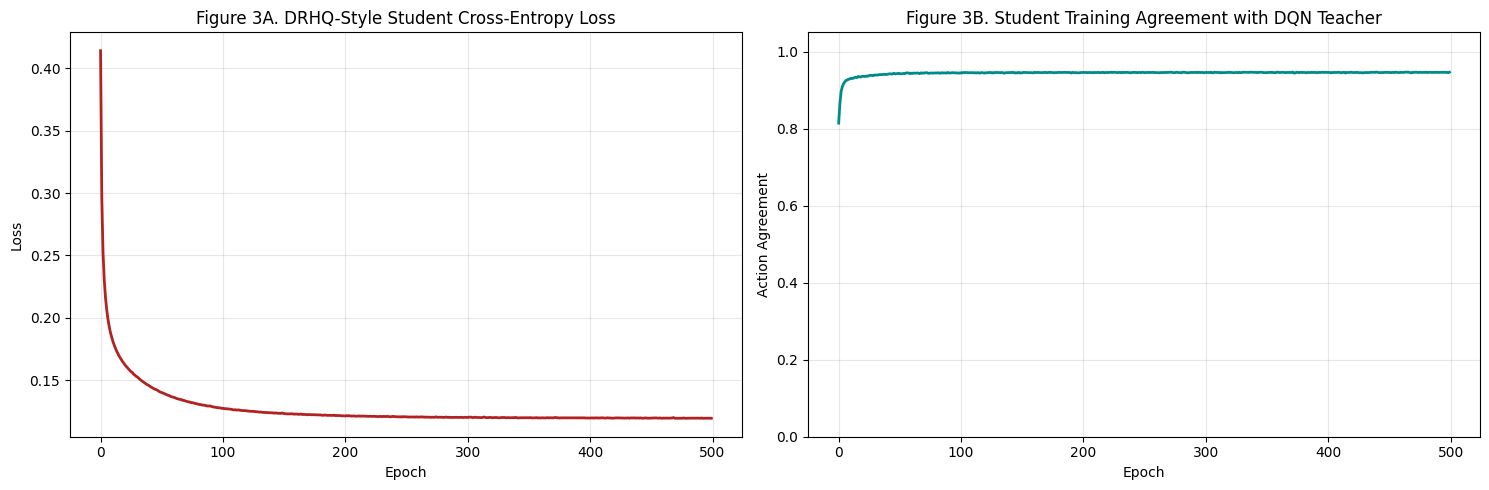

TABLE C: Learned interpretable parameters


,Feature,NS Weight,EW Weight,NS Exponent,EW Exponent
0,Stopped vehicles,55.861000,41.884998,0.500,0.500
1,Approaching vehicles,0.062000,0.003000,1.990,1.957
2,Cumulative waiting time,0.000000,0.000000,1.962,1.921
3,Average waiting time,42.307999,51.555000,0.500,0.500
4,Average queue length,55.861000,41.884998,0.500,0.500
5,Average approaching speed,0.000000,0.000000,1.995,1.992



TABLE D: Learned phase-switching penalties


,Action,Learned Switching Penalty
0,NS,7.065
1,EW,5.647



Saved DRHQ-style training plot and parameter tables.


In [ ]:
# Plot student imitation training.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(student_loss_history, color="#B22222", linewidth=2)
axes[0].set_title("Figure 3A. DRHQ-Style Student Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(student_accuracy_history, color="#008B8B", linewidth=2)
axes[1].set_title("Figure 3B. Student Training Agreement with DQN Teacher")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Action Agreement")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()

student_training_plot_path = OUTPUT_DIR / "drhq_student_training_curves.png"
plt.savefig(student_training_plot_path, dpi=250, bbox_inches="tight")
plt.show()

# Convert learned model parameters into a readable table.
learned_weights, learned_exponents, learned_penalties = student_model.readable_parameters()

feature_names = [
    "Stopped vehicles",
    "Approaching vehicles",
    "Cumulative waiting time",
    "Average waiting time",
    "Average queue length",
    "Average approaching speed"
]

parameter_table = pd.DataFrame({
    "Feature": feature_names,
    "NS Weight": learned_weights[0],
    "EW Weight": learned_weights[1],
    "NS Exponent": learned_exponents[0],
    "EW Exponent": learned_exponents[1]
})

switch_penalty_table = pd.DataFrame({
    "Action": ["NS", "EW"],
    "Learned Switching Penalty": learned_penalties
})

print("TABLE C: Learned interpretable parameters")
display(parameter_table.round(3))

print("\nTABLE D: Learned phase-switching penalties")
display(switch_penalty_table.round(3))

parameter_table.to_csv(
    OUTPUT_DIR / "interpretable_student_parameters.csv",
    index=False
)

switch_penalty_table.to_csv(
    OUTPUT_DIR / "interpretable_student_switch_penalties.csv",
    index=False
)

print("\nSaved DRHQ-style training plot and parameter tables.")

# 7. Final Evaluation Method

The final comparison evaluates three controllers:

1. **Actuated baseline**  
   Selects the signal group with the larger stopped queue.

2. **DQN teacher**  
   Uses a neural network to select the action with the highest learned Q-value.

3. **Interpretable DRHQ-style student**  
   Uses a monotonic precedence score trained to imitate the DQN teacher's preferred action.

## Fair Evaluation Rule

For every test seed and demand level, all controllers receive the same traffic-arrival sequence.

## Metrics

| Metric | Meaning |
|---|---|
| Average delay | Mean waiting delay per vehicle |
| Cumulative queue | Sum of the queue size across simulation time |
| Vehicles departed | Number of vehicles successfully served |
| Delay reduction | Improvement relative to actuated baseline |

The delay reduction is calculated as:

$$
\text{Delay Reduction (\%)} =
\frac{
\text{Baseline Average Delay} -
\text{Controller Average Delay}
}{
\text{Baseline Average Delay}
}
\times 100
$$

> A positive percentage means that the controller reduced delay relative to the actuated baseline.

### Evaluate Baseline, DQN Teacher, and Interpretable Student

In [ ]:
def dqn_policy(state):
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    with torch.no_grad():
        return int(torch.argmax(dqn_teacher(state_tensor), dim=1).item())


def interpretable_student_policy(state):
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    with torch.no_grad():
        return int(torch.argmax(student_model(state_tensor), dim=1).item())


def run_policy_episode(policy_function, demand_level, seed, horizon=160):
    environment = SimplifiedTrafficEnv(
        horizon=horizon,
        demand_level=demand_level,
        seed=seed
    )

    state = environment.reset(seed=seed)
    done = False

    while not done:
        action = policy_function(state)
        state, _, done, _ = environment.step(action)

    metrics = calculate_episode_metrics(environment)

    metrics["queue_history"] = environment.queue_history
    metrics["delay_history"] = environment.delay_history
    metrics["action_history"] = environment.action_history

    return metrics


evaluation_records = []
evaluation_details = {}

demand_levels = ["low", "medium", "high"]
evaluation_seeds = list(range(500, 520))

policy_dictionary = {
    "Actuated Baseline": actuated_policy,
    "DQN Teacher": dqn_policy,
    "Interpretable Student": interpretable_student_policy
}

for demand_level in demand_levels:
    evaluation_details[demand_level] = {}

    for policy_name, policy_function in policy_dictionary.items():
        policy_results = []

        for seed in evaluation_seeds:
            result = run_policy_episode(
                policy_function=policy_function,
                demand_level=demand_level,
                seed=seed
            )

            policy_results.append(result)

        evaluation_details[demand_level][policy_name] = policy_results

        evaluation_records.append({
            "Demand Level": demand_level.title(),
            "Controller": policy_name,
            "Average Delay": np.mean([item["average_delay"] for item in policy_results]),
            "Delay Std Dev": np.std([item["average_delay"] for item in policy_results]),
            "Cumulative Queue": np.mean([item["cumulative_queue"] for item in policy_results]),
            "Vehicles Departed": np.mean([item["vehicles_departed"] for item in policy_results]),
            "Remaining Vehicles": np.mean([item["remaining_vehicles"] for item in policy_results])
        })

evaluation_table = pd.DataFrame(evaluation_records)

# Calculate percentage delay reduction relative to baseline.
baseline_delay_lookup = evaluation_table[
    evaluation_table["Controller"] == "Actuated Baseline"
].set_index("Demand Level")["Average Delay"].to_dict()

evaluation_table["Delay Reduction vs Baseline (%)"] = evaluation_table.apply(
    lambda row: (
        (baseline_delay_lookup[row["Demand Level"]] - row["Average Delay"])
        / baseline_delay_lookup[row["Demand Level"]]
        * 100
    ),
    axis=1
)

print("TABLE E: Final evaluation of all controllers")
display(evaluation_table.round(3))

evaluation_table.to_csv(
    OUTPUT_DIR / "final_controller_evaluation.csv",
    index=False
)

print("\nSaved final evaluation table.")

TABLE E: Final evaluation of all controllers


,Demand Level,Controller,Average Delay,Delay Std Dev,Cumulative Queue,Vehicles Departed,Remaining Vehicles,Delay Reduction vs Baseline (%)
0,Low,Actuated Baseline,4.016,1.507,1117.50,264.35,7.80,0.000
1,Low,DQN Teacher,1.973,0.190,539.05,270.00,2.15,50.879
2,Low,Interpretable Student,1.999,0.183,546.15,269.85,2.30,50.233
3,Medium,Actuated Baseline,19.476,3.985,8520.45,341.35,94.50,0.000
4,Medium,DQN Teacher,3.703,0.600,1624.10,427.35,8.50,80.984
5,Medium,Interpretable Student,3.750,0.678,1644.45,427.30,8.55,80.747
6,High,Actuated Baseline,32.807,3.345,19647.35,360.55,236.70,0.000
7,High,DQN Teacher,9.568,1.817,5751.05,547.20,50.05,70.835
8,High,Interpretable Student,10.270,2.157,6179.00,540.45,56.80,68.696



Saved final evaluation table.


### Generate Final Result Figures

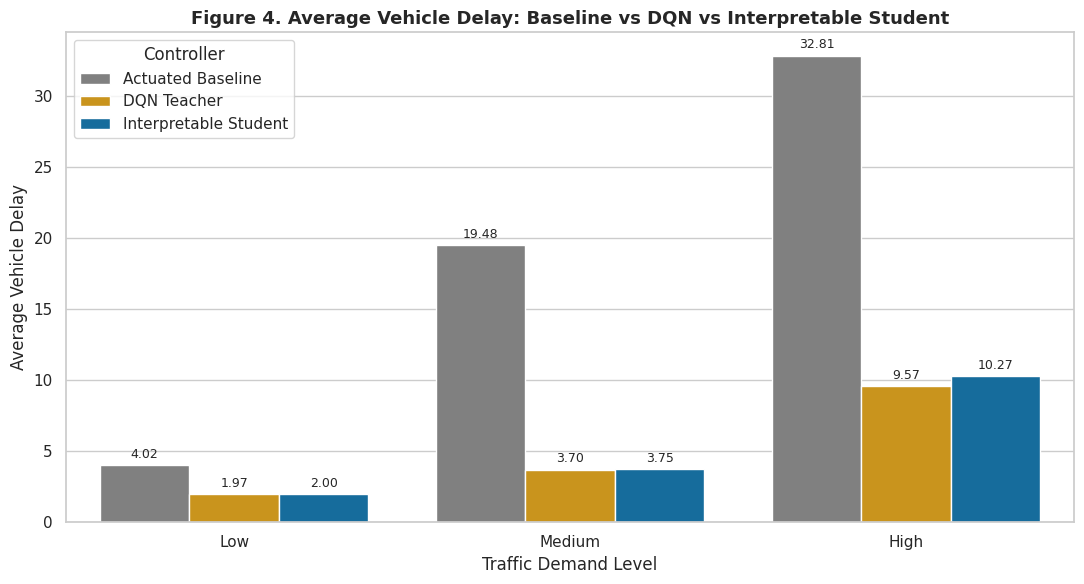

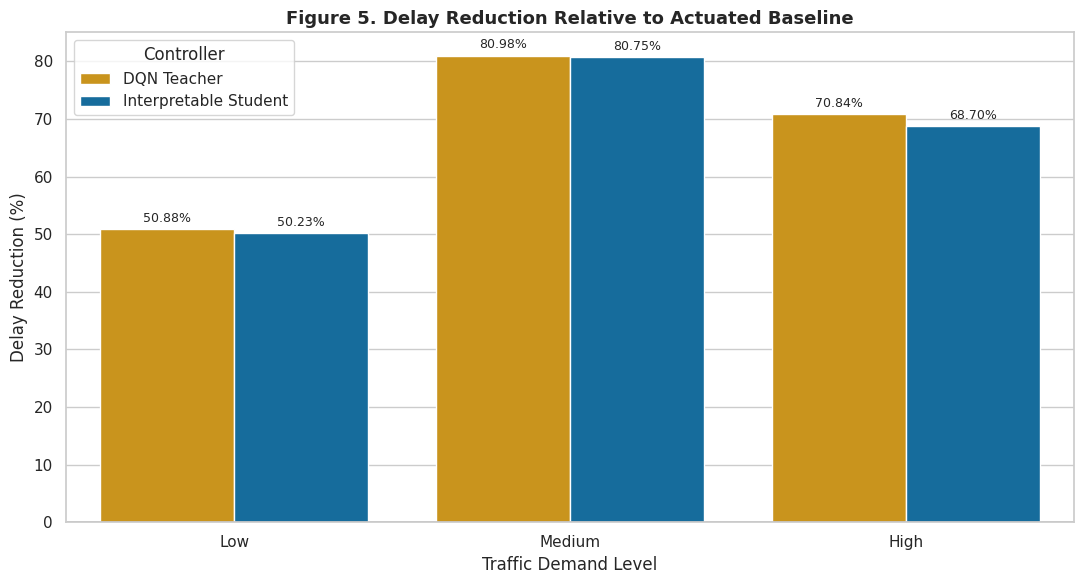

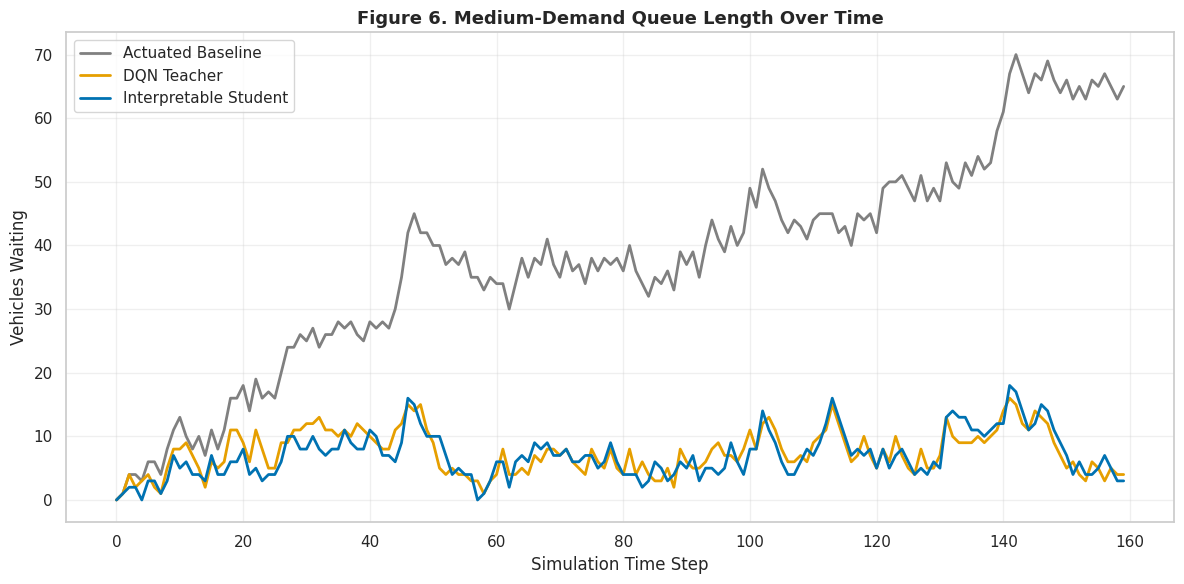

Saved figures:
- traffic_signal_proof_outputs/average_delay_comparison.png
- traffic_signal_proof_outputs/delay_reduction_comparison.png
- traffic_signal_proof_outputs/medium_demand_queue_history.png


In [ ]:
# Create bar charts and a queue-history comparison.

sns.set_theme(style="whitegrid")

# Figure 4: Average delay comparison
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=evaluation_table,
    x="Demand Level",
    y="Average Delay",
    hue="Controller",
    ax=ax,
    palette=["#808080", "#E69F00", "#0072B2"]
)

ax.set_title(
    "Figure 4. Average Vehicle Delay: Baseline vs DQN vs Interpretable Student",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("Average Vehicle Delay")
ax.set_xlabel("Traffic Demand Level")
ax.legend(title="Controller")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()

average_delay_plot_path = OUTPUT_DIR / "average_delay_comparison.png"
plt.savefig(average_delay_plot_path, dpi=250, bbox_inches="tight")
plt.show()

# Figure 5: Delay reduction relative to baseline
non_baseline_results = evaluation_table[
    evaluation_table["Controller"] != "Actuated Baseline"
].copy()

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=non_baseline_results,
    x="Demand Level",
    y="Delay Reduction vs Baseline (%)",
    hue="Controller",
    ax=ax,
    palette=["#E69F00", "#0072B2"]
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title(
    "Figure 5. Delay Reduction Relative to Actuated Baseline",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel("Delay Reduction (%)")
ax.set_xlabel("Traffic Demand Level")
ax.legend(title="Controller")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()

delay_reduction_plot_path = OUTPUT_DIR / "delay_reduction_comparison.png"
plt.savefig(delay_reduction_plot_path, dpi=250, bbox_inches="tight")
plt.show()

# Figure 6: Queue histories for a fixed medium-demand test scenario
demonstration_seed = 777

baseline_demo = run_policy_episode(
    actuated_policy,
    demand_level="medium",
    seed=demonstration_seed
)

teacher_demo = run_policy_episode(
    dqn_policy,
    demand_level="medium",
    seed=demonstration_seed
)

student_demo = run_policy_episode(
    interpretable_student_policy,
    demand_level="medium",
    seed=demonstration_seed
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    baseline_demo["queue_history"],
    label="Actuated Baseline",
    linewidth=2,
    color="#808080"
)

ax.plot(
    teacher_demo["queue_history"],
    label="DQN Teacher",
    linewidth=2,
    color="#E69F00"
)

ax.plot(
    student_demo["queue_history"],
    label="Interpretable Student",
    linewidth=2,
    color="#0072B2"
)

ax.set_title(
    "Figure 6. Medium-Demand Queue Length Over Time",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Simulation Time Step")
ax.set_ylabel("Vehicles Waiting")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

queue_history_plot_path = OUTPUT_DIR / "medium_demand_queue_history.png"
plt.savefig(queue_history_plot_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("-", average_delay_plot_path)
print("-", delay_reduction_plot_path)
print("-", queue_history_plot_path)

### Decision Audit Table: Explain One Interpretable Decision

In [ ]:
# This cell shows why the interpretable student selects an action
# for one representative traffic state.

audit_environment = SimplifiedTrafficEnv(
    horizon=160,
    demand_level="high",
    seed=999
)

audit_state = audit_environment.reset(seed=999)

# Create a non-empty traffic state by running the baseline for 25 steps.
for _ in range(25):
    audit_action = actuated_policy(audit_state)
    audit_state, _, _, _ = audit_environment.step(audit_action)

with torch.no_grad():
    state_tensor = torch.tensor(
        audit_state,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    student_scores = student_model(state_tensor).cpu().numpy()[0]
    teacher_q_values = dqn_teacher(state_tensor).cpu().numpy()[0]

audit_feature_values = audit_state[:12].reshape(2, 6)
audit_switch_flags = audit_state[12:14]

audit_table = pd.DataFrame({
    "Feature": feature_names,
    "NS Feature Value": audit_feature_values[0],
    "EW Feature Value": audit_feature_values[1],
    "NS Weight": learned_weights[0],
    "EW Weight": learned_weights[1],
    "NS Exponent": learned_exponents[0],
    "EW Exponent": learned_exponents[1]
})

decision_table = pd.DataFrame({
    "Candidate Action": ["NS", "EW"],
    "Switch Flag": audit_switch_flags,
    "Interpretable Precedence Score": student_scores,
    "DQN Teacher Q-Value": teacher_q_values
})

selected_student_action = ACTION_NAMES[int(np.argmax(student_scores))]
selected_teacher_action = ACTION_NAMES[int(np.argmax(teacher_q_values))]

print("TABLE F: Feature-level explanation of one traffic-signal decision")
display(audit_table.round(3))

print("\nTABLE G: Action-level decision audit")
display(decision_table.round(3))

print("\nInterpretable student selected action:", selected_student_action)
print("DQN teacher selected action:", selected_teacher_action)

audit_table.to_csv(
    OUTPUT_DIR / "interpretable_decision_feature_audit.csv",
    index=False
)

decision_table.to_csv(
    OUTPUT_DIR / "interpretable_decision_action_audit.csv",
    index=False
)

TABLE F: Feature-level explanation of one traffic-signal decision


,Feature,NS Feature Value,EW Feature Value,NS Weight,EW Weight,NS Exponent,EW Exponent
0,Stopped vehicles,0.700,0.700,55.861000,41.884998,0.500,0.500
1,Approaching vehicles,0.607,0.441,0.062000,0.003000,1.990,1.957
2,Cumulative waiting time,0.410,0.860,0.000000,0.000000,1.962,1.921
3,Average waiting time,0.293,0.614,42.307999,51.555000,0.500,0.500
4,Average queue length,0.700,0.700,55.861000,41.884998,0.500,0.500
5,Average approaching speed,0.162,0.118,0.000000,0.000000,1.995,1.992



TABLE G: Action-level decision audit


,Candidate Action,Switch Flag,Interpretable Precedence Score,DQN Teacher Q-Value
0,NS,0.0,16.028,-317.781006
1,EW,1.0,10.810,-351.190002



Interpretable student selected action: NS
DQN teacher selected action: NS


# 8. Results Interpretation, Limitations, and Future Work

## How to Interpret Our Generated Results

After executing the notebook, use **Table E**, **Figure 4**, **Figure 5**, and **Figure 6** as evidence in the PPT.

- **Table E** compares average delay, variability, throughput, and delay reduction.
- **Figure 4** compares average delay across low, medium, and high traffic demand.
- **Figure 5** shows percentage improvement or deterioration relative to the actuated baseline.
- **Figure 6** shows the queue size over time for the same medium-demand scenario.
- **Tables F and G** provide a human-readable explanation of one individual student decision.

## Expected Interpretation

- The DQN teacher may achieve good performance because it can represent complex decision boundaries.
- The interpretable student may have slightly lower performance because it is constrained to a monotonic and transparent form.
- High imitation accuracy indicates that the interpretable student often selects the same action as the DQN teacher.
- A transparent policy is valuable when accountability and human intervention are required.

## Results Reported by the Original Paper

The paper found that:

- DQN produced the strongest overall delay performance but was not interpretable.
- Vanilla DRQ performed poorly because directly matching numerical Q-values was too restrictive.
- DRSQ and DRHQ outperformed PPO.
- DRHQ had a small but significant advantage over DRSQ in low demand.
- DRHQ was competitive with actuated control after one episode in low and medium demand.
- In high demand, DRHQ exceeded actuated performance after 20 episodes when exploration was reduced.
- The optimized DRHQ policy achieved up to **19.4 percent delay reduction** relative to an actuated controller.

## Limitations

1. The original study was simulation-based; SUMO cannot capture every real-world uncertainty.
2. Real deployment involves sensor noise, pedestrians, driver behavior, communication delay, failures, and legal safety constraints.
3. CMA-ES required too many full episodes and explored unsafe parameter settings.
4. PPO showed smooth exploration but converged slowly and could become trapped in weaker local optima.
5. The original paper studied a single intersection, not a city-wide coordinated traffic network.
6. This Colab notebook is a simplified educational implementation and not an exact SUMO replication.

## Future Work

- Warm-start learning from an existing actuated controller.
- Train in simulation before any real-world deployment.
- Use offline historical data and safe policy constraints.
- Extend to multiple coordinated intersections.
- Incorporate pedestrians, emergency vehicles, sensor uncertainty, and fairness constraints.

### Save Final Summary and List All Evidence Files

In [ ]:
# Create a compact summary file and show all proof-of-work artifacts.

final_summary = evaluation_table.copy()

final_summary["Interpretation"] = np.where(
    final_summary["Delay Reduction vs Baseline (%)"] > 0,
    "Lower delay than the actuated baseline.",
    "No delay reduction relative to the actuated baseline in this simplified experiment."
)

final_summary.to_csv(
    OUTPUT_DIR / "final_presentation_summary.csv",
    index=False
)

print("=" * 75)
print("FINAL PROOF-OF-WORK SUMMARY")
print("=" * 75)

print("\nDQN-to-Student Imitation Accuracy")
print(f"{test_imitation_accuracy * 100:.2f}%")

print("\nFinal Controller Evaluation")
display(final_summary.round(3))

print("\nFiles Generated for Screenshots, PPT, and Submission Evidence")
for file_path in sorted(OUTPUT_DIR.iterdir()):
    print("-", file_path.name)

print("\nSuggested final PPT links:")
print("Paper: https://arxiv.org/pdf/1912.11023")
print("Original authors' repository: https://github.com/jault/StateStreetSumo")
print("Add your Colab notebook link and Google Drive video link on the final PPT slide.")

FINAL PROOF-OF-WORK SUMMARY

DQN-to-Student Imitation Accuracy
95.12%

Final Controller Evaluation


,Demand Level,Controller,Average Delay,Delay Std Dev,Cumulative Queue,Vehicles Departed,Remaining Vehicles,Delay Reduction vs Baseline (%),Interpretation
0,Low,Actuated Baseline,4.016,1.507,1117.50,264.35,7.80,0.000,No delay reduction relative to the actuated ba...
1,Low,DQN Teacher,1.973,0.190,539.05,270.00,2.15,50.879,Lower delay than the actuated baseline.
2,Low,Interpretable Student,1.999,0.183,546.15,269.85,2.30,50.233,Lower delay than the actuated baseline.
3,Medium,Actuated Baseline,19.476,3.985,8520.45,341.35,94.50,0.000,No delay reduction relative to the actuated ba...
4,Medium,DQN Teacher,3.703,0.600,1624.10,427.35,8.50,80.984,Lower delay than the actuated baseline.
5,Medium,Interpretable Student,3.750,0.678,1644.45,427.30,8.55,80.747,Lower delay than the actuated baseline.
6,High,Actuated Baseline,32.807,3.345,19647.35,360.55,236.70,0.000,No delay reduction relative to the actuated ba...
7,High,DQN Teacher,9.568,1.817,5751.05,547.20,50.05,70.835,Lower delay than the actuated baseline.
8,High,Interpretable Student,10.270,2.157,6179.00,540.45,56.80,68.696,Lower delay than the actuated baseline.



Files Generated for Screenshots, PPT, and Submission Evidence
- average_delay_comparison.png
- delay_reduction_comparison.png
- dqn_teacher_training_curves.png
- dqn_teacher_training_history.csv
- drhq_student_training_curves.png
- final_controller_evaluation.csv
- final_presentation_summary.csv
- interpretable_decision_action_audit.csv
- interpretable_decision_feature_audit.csv
- interpretable_student_parameters.csv
- interpretable_student_switch_penalties.csv
- medium_demand_queue_history.png
- paper_findings_summary.csv
- paper_traffic_demand_table.csv
- simplified_intersection_diagram.png

Suggested final PPT links:
Paper: https://arxiv.org/pdf/1912.11023
Original authors' repository: https://github.com/jault/StateStreetSumo
Add your Colab notebook link and Google Drive video link on the final PPT slide.


# 10. References

1. Ault, J., Hanna, J. P., and Sharon, G. (2020).  
   *Learning an Interpretable Traffic Signal Control Policy.*  
   Proceedings of the 19th International Conference on Autonomous Agents and Multiagent Systems.  
   https://arxiv.org/pdf/1912.11023

2. Ault, J.  
   *StateStreetSumo: Source code associated with the traffic-signal experiments.*  
   https://github.com/jault/StateStreetSumo

3. Krajzewicz, D., Erdmann, J., Behrisch, M., and Bieker, L. (2012).  
   Recent Development and Applications of SUMO – Simulation of Urban MObility.  
   https://sumo.dlr.de/docs/index.html

4. Mnih, V., et al. (2015).  
   Human-level control through deep reinforcement learning.  
   *Nature*, 518, 529–533.

5. Schulman, J., et al. (2017).  
   Proximal Policy Optimization Algorithms.  
   https://arxiv.org/abs/1707.06347

6. Utah Department of Transportation.  
   Automated Traffic Signal Performance Measures.  
   https://udottraffic.utah.gov/ATSPM